In [2]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.colors as mcolors
import matplotlib.cm as cmaps

from matplotlib.colors import BoundaryNorm



import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

brbg = cmaps.get_cmap('BrBG')
rdbur = cmaps.get_cmap('RdBu_r')



from pylab import rcParams
rcParams['axes.labelweight'] = 'bold'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'bold'

### Panel a-f


In [3]:

fig4 = xr.open_dataset("../preprocessed_data/fig3af.nc")

tp_by_qs = fig4["tp_by_qs"].values
tp_by_qs_compound = fig4["tp_by_qs_compound"].values
tp_clim_by_qs = fig4["tp_clim_by_qs"].values
all_tp_by_qs = fig4["all_tp_by_qs"].values

sst_by_qs = fig4["sst_by_qs"].values
sst_by_qs_compound = fig4["sst_by_qs_compound"].values
sst_clim_by_qs = fig4["sst_clim_by_qs"].values
all_sst_by_qs = fig4["all_sst_by_qs"].values

sst_by_qs_diff = sst_by_qs-sst_by_qs_compound
tp_by_qs_diff = tp_by_qs - tp_by_qs_compound

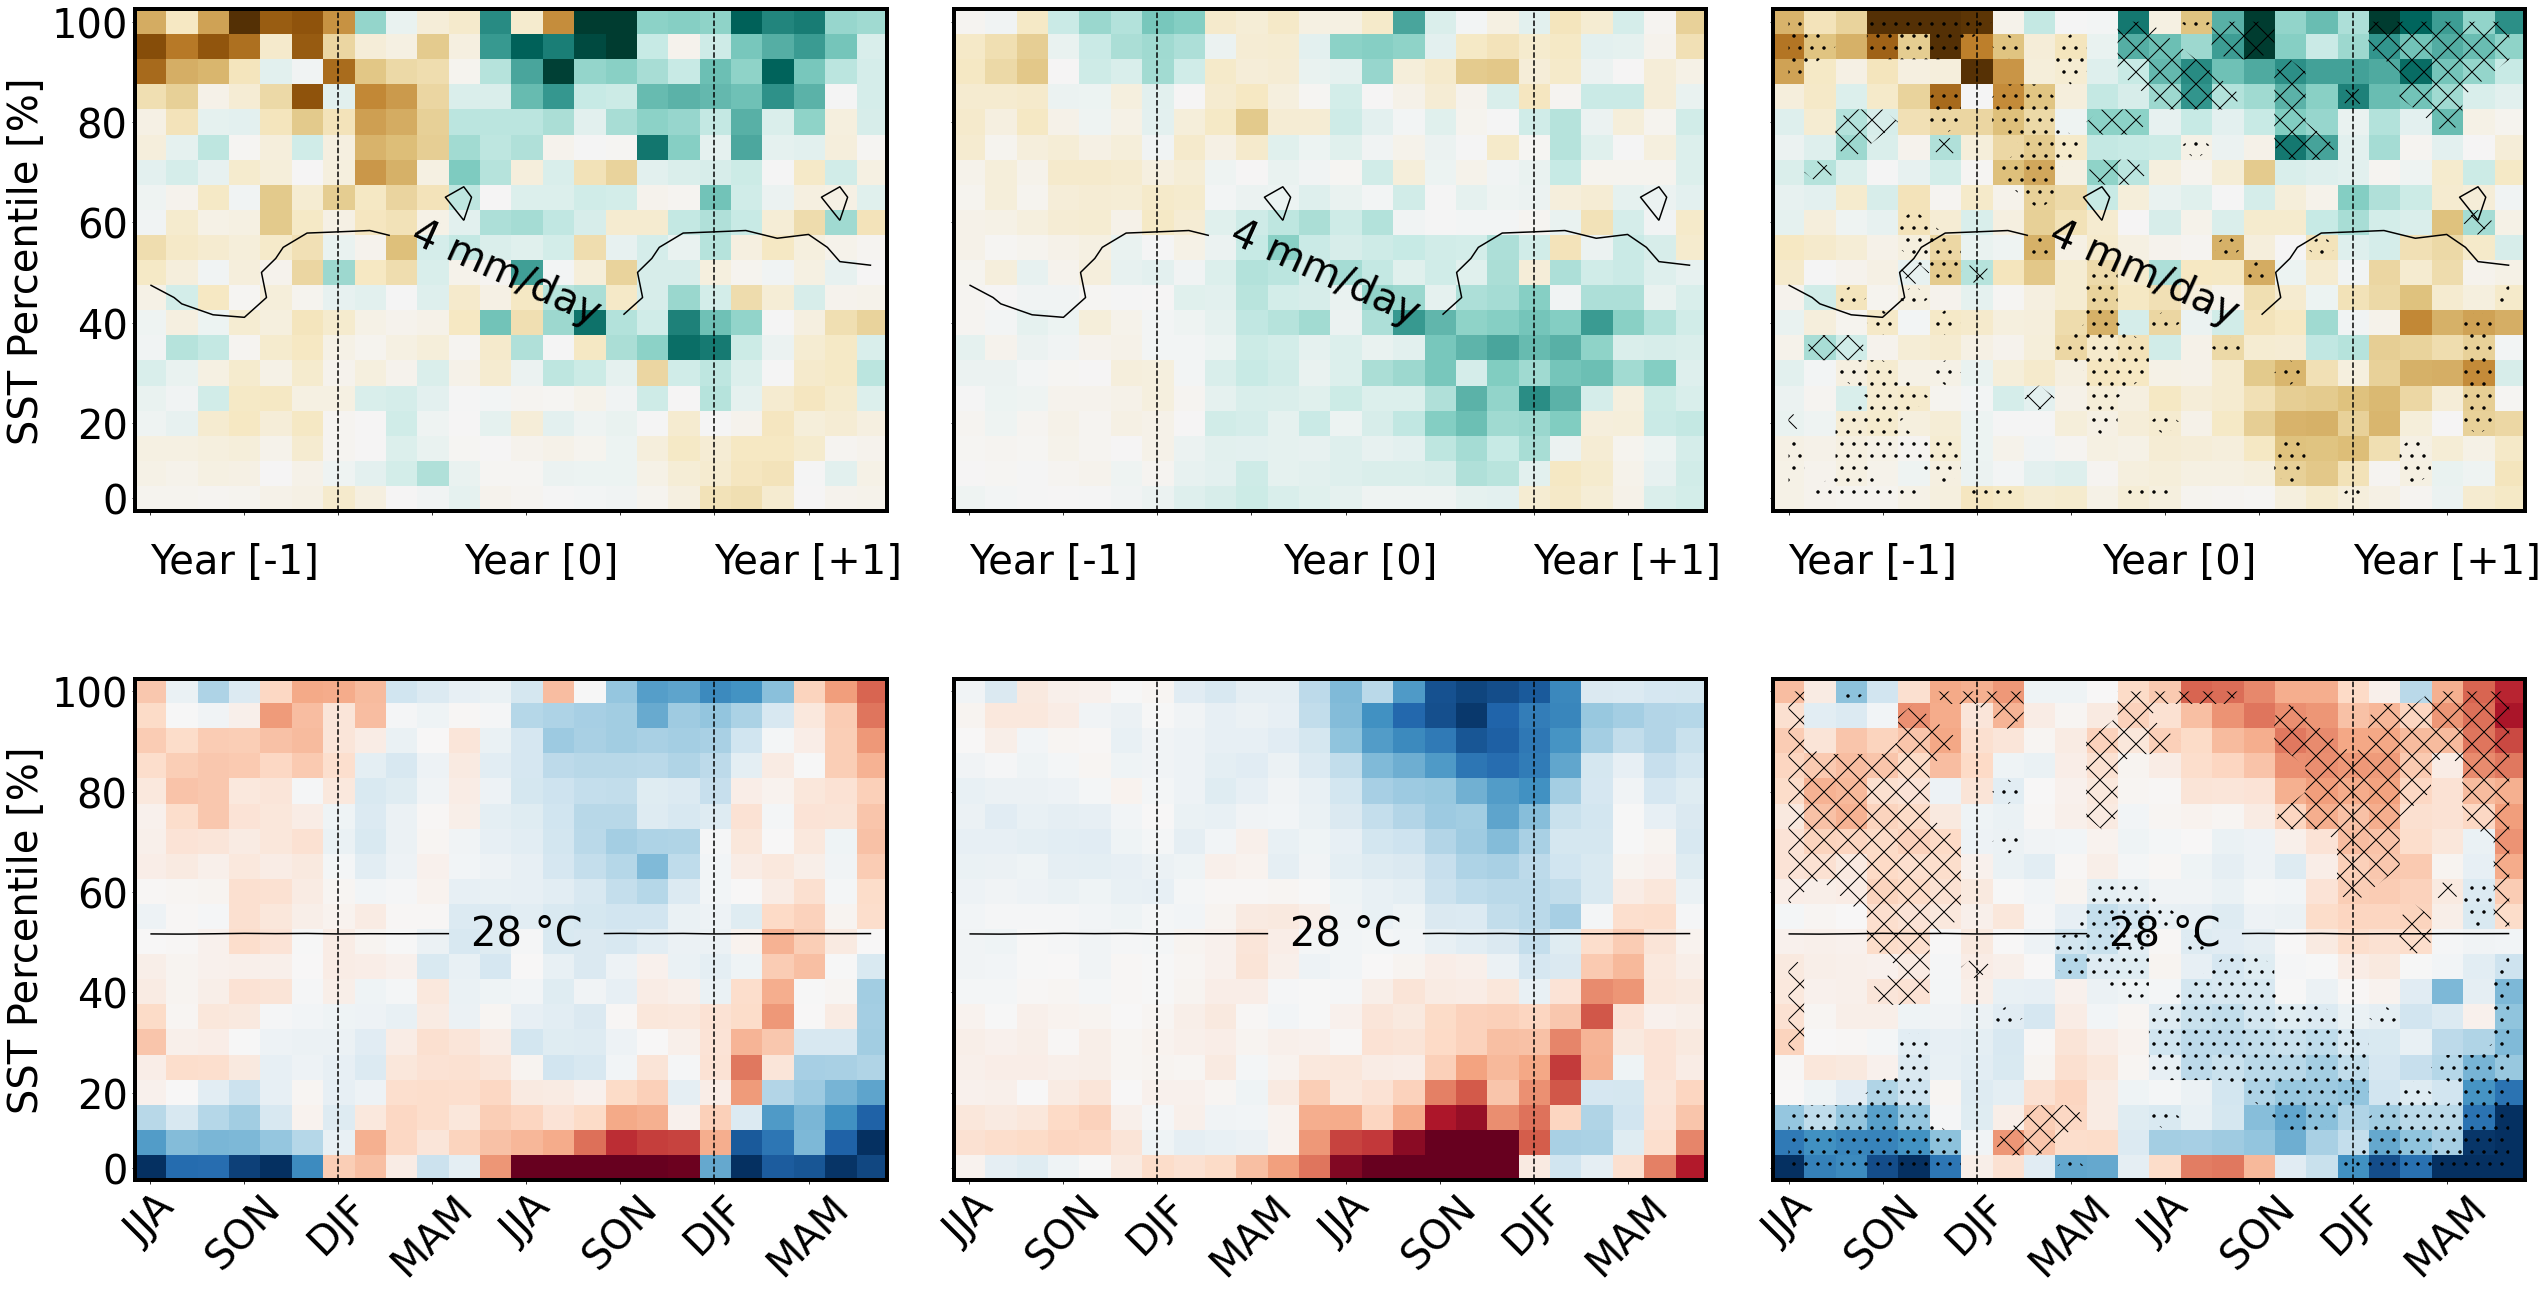

In [4]:


add_cbar = False

# Create the plot
fig, axs = plt.subplots(2,3, figsize=(36, 20), sharex = True, sharey = True)


smax = 0.8

# Display the data using imshow
img = axs[1,0].imshow(
    sst_by_qs, cmap='RdBu_r', vmin = -smax, vmax = smax,
    interpolation='none', origin='lower',
    aspect = .8
)

# Display the data using imshow
img = axs[1,1].imshow(
    sst_by_qs_compound, cmap='RdBu_r', vmin = -smax, vmax = smax,
    interpolation='none', origin='lower',
    aspect = .8
)

# Display the data using imshow
imgs = axs[1,2].imshow(
    sst_by_qs_diff, cmap='RdBu_r', vmin = -smax, vmax = smax,
    interpolation='none', origin='lower',
    aspect = .8
)

# Add color bar with label
if add_cbar:

    cbar = plt.colorbar(imgs, ax=axs[1,2], pad=0.02, extend = 'both', shrink = 0.6)
    cbar.set_label('SST Anomaly [K]', fontsize=40, fontweight = 'normal')


comparison = sst_by_qs>all_sst_by_qs
mask_all_larger = comparison.all(axis = 0)
#mask_at_least_four_larger = comparison.sum(axis = 0) >=5

comparison = sst_by_qs<all_sst_by_qs
mask_all_smaller = comparison.all(axis = 0)
#mask_at_least_four_smaller = comparison.sum(axis = 0) >=5

#------------------------------hatching
#hatching
# Add diagonal hatching for significant regions
axs[1,2].contourf(
    mask_all_larger,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['/'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)


# Add diagonal hatching for significant regions
axs[1,2].contourf(
    mask_all_larger,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['\\'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)


# Add diagonal hatching for significant regions
axs[1,2].contourf(
    mask_all_smaller,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['.'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)
##----------------------Precip--------------------


# Display the data using imshow
img = axs[0,0].imshow(
    tp_by_qs, cmap='BrBG', vmin=-2., vmax=2.,
    interpolation='none', origin='lower',
    aspect = .8
)

# Display the data using imshow
img = axs[0,1].imshow(
    tp_by_qs_compound, cmap='BrBG', vmin=-2., vmax=2.,
    interpolation='none', origin='lower',
    aspect = .8
)

# Display the data using imshow
img= axs[0,2].imshow(
    tp_by_qs_diff, cmap='BrBG', vmin=-2., vmax=2.,
    interpolation='none', origin='lower',
    aspect = .8
)


# Add color bar with label
if add_cbar:
    cbar = plt.colorbar(img, ax = axs[0,2], pad=0.02, extend = 'both', shrink = 0.6)
    cbar.set_label('TP Anomaly [mm/day]', fontsize=40, fontweight = 'normal')




comparison = tp_by_qs>all_tp_by_qs
mask_all_larger = comparison.all(axis = 0)
#mask_at_least_four_larger = comparison.sum(axis = 0) >=5

comparison = tp_by_qs<all_tp_by_qs
mask_all_smaller = comparison.all(axis = 0)
#mask_at_least_four_smaller = comparison.sum(axis = 0) >=5

#------------------------------hatching
#hatching
# Add diagonal hatching for significant regions
axs[0,2].contourf(
    mask_all_larger,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['/'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)


# Add diagonal hatching for significant regions
axs[0,2].contourf(
    mask_all_larger,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['\\'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)

# Add diagonal hatching for significant regions
axs[0,2].contourf(
    mask_all_smaller,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['.'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)



for ax in axs[1,:]:
    cs = ax.contour(sst_clim_by_qs-273.15, levels = [28], colors = 'k', )
    ax.clabel(cs, cs.levels, fmt = '28 °C', fontsize = 40)
    
    
for ax in axs[0,:]:
    cs = ax.contour(tp_clim_by_qs, levels = [4], colors = 'k', )
    ax.clabel(cs, cs.levels, fmt = '4 mm/day', fontsize = 40)

##-----------------tuning the graphics------------


# Set y-axis labels
yticks = np.linspace(0, tp_by_qs.shape[0] - 1, 6).astype(int)  # Adjust ticks for clarity
ylabels = np.linspace(0, 100, len(yticks)).astype(int)  # Percentile labels
for ax in axs[:,0]:
    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels, fontsize= 40)
    ax.set_ylabel('SST Percentile [%]', fontsize=40, fontweight = 'normal')

# Set x-axis labels
xticks = [0,3,6,9, 12,15, 18, 21]  # Adjust ticks for clarity
xlabels = ['JJA', 'SON', 'DJF', 'MAM', 'JJA', 'SON', 'DJF', 'MAM']  # Representative months
for ax in axs[1,:]:
    ax.set_xticks(xticks)
    ax.set_xticklabels(xlabels, rotation = 45, fontsize = 40)
    
for ax in axs[0,:]:    
    ax.text(0,-3, 'Year [-1]', fontsize = 40, fontweight = 'normal')
    ax.text(10,-3, 'Year [0]', fontsize = 40, fontweight = 'normal')
    ax.text(18,-3, 'Year [+1]', fontsize = 40, fontweight = 'normal')
    

for ax in axs.flatten():
    ax.axvline(6, linestyle = '--', c = 'k')
    ax.axvline(18, linestyle = '--', c = 'k')

# Add a thick frame around the plot
for ax in axs.flatten():   
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(4)


plt.tight_layout()


### Panel g

In [5]:
tp = xr.open_dataset("../preprocessed_data/fig3g.nc")
sst = xr.open_dataset("../preprocessed_data/fig3h.nc")




#compute variablity
q10tp = tp.quantile(0.1, dim = 'year')
q90tp = tp.quantile(0.9, dim = 'year')
#make composite
cyears =  [1982, 1987, 1991, 1997, 2009, 2015]
cmtp = tp.where(tp.year.isin(cyears), drop = True).mean('year')
cstdtp = tp.where(tp.year.isin(cyears), drop = True).std('year')


#compute variablity
q10 = sst.quantile(0.1, dim = 'year')
q90 = sst.quantile(0.9, dim = 'year') 

# make composite
cm = sst.where(sst.year.isin(cyears), drop = True).mean('year')
cm_1 = sst.where(sst.year.isin([y-1 for y in cyears]), drop = True).mean('year')
cstd = sst.where(sst.year.isin(cyears), drop = True).std('year')

#compute variablity
cq10 = sst.where(sst.year.isin(cyears), drop = True).min(dim = 'year')
cq90 = sst.where(sst.year.isin(cyears), drop = True).max(dim = 'year') 

#compute variablity
cq10tp = tp.where(tp.year.isin(cyears), drop = True).min(dim = 'year')
cq90tp = tp.where(tp.year.isin(cyears), drop = True).max(dim = 'year') 


/home/jmex/.conda/envs/myenv-3.9/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1389: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,
/home/jmex/.conda/envs/myenv-3.9/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1389: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,


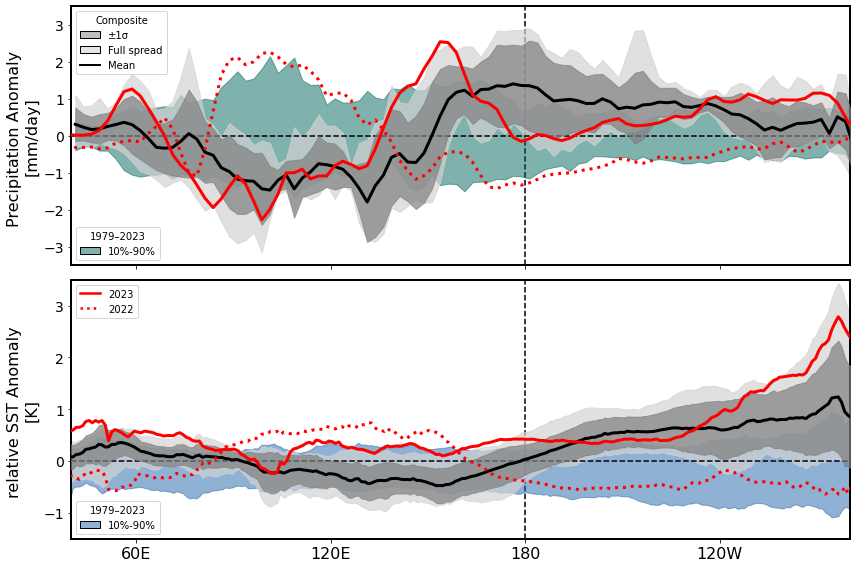

In [6]:
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(12, 8))


#------------------PRECIP NOW ON TOP-----------------------
ax = axs[0]  # Precip on the top

# plot variability (nino)
ax.fill_between(cstdtp.lon, (cmtp + cstdtp).tp, (cmtp - cstdtp).tp,
                color='grey', alpha=0.7, label='+/- σ', zorder=10)

# all variability
ax.fill_between(q10tp.lon, q10tp.tp, q90tp.tp,
                color=brbg(0.9), alpha=0.5, label='10%-90% of (1979-2024)')

ax.fill_between(cq10tp.lon, cq10tp.tp, cq90tp.tp,
                color = 'lightgrey', alpha = 0.7, label = 'Full Spread Composite')


"""cq10tp.tp.plot(ax = ax, linestyle = 'dotted', c = 'k')
cq90tp.tp.plot(ax = ax, linestyle = 'dotted', c = 'k')
"""

tp.sel(year=2023).rolling(lon = 3, center=True, min_periods = 1).mean().tp.plot(ax=ax, c='r', linewidth=3, label='2023', zorder=15)
tp.sel(year=2022).rolling(lon = 3, center=True, min_periods = 1).mean().tp.plot(ax=ax, c='red', linestyle='dotted', linewidth=3, label='2022', zorder=14)
cmtp.tp.plot(c='k', label='Composite', zorder=12, ax=ax, linewidth = 3)
#cmtp_1.tp.plot(c='k', label='Composite [-1]', zorder=12, ax=ax, linestyle='--')


ax.set_ylim(-3.5, 3.5)
ax.axhline(0, c='k', linestyle='--')
ax.set_ylabel('Precipitation Anomaly \n[mm/day]', fontweight='normal', fontsize=16)

#------------------SST NOW ON BOTTOM-----------------------
ax = axs[1]  # SST on the bottom

# plot variability (nino)
ax.fill_between(cstd.lon, (cm + cstd).sst, (cm - cstd).sst,
                color='grey', alpha=0.7, label='+/- σ', zorder=10)

# all variability
ax.fill_between(q10.lon, q10.sst, q90.sst,
                color=rdbur(0.1), alpha=0.5, label='10%-90% of (1979-2024)')
#all variability
ax.fill_between(cq10.lon, cq10.sst, cq90.sst,
                color = 'lightgrey', alpha = 0.7, label = 'Full Spread Composite')

"""cq10.sst.plot(ax = ax, linestyle = 'dotted', c = 'k')
cq90.sst.plot(ax = ax, linestyle = 'dotted', c = 'k', label = 'Full Spread Composite')
"""

sst.sel(year=2023).sst.plot(ax=ax, c='r', linewidth=3, label='2023', zorder=15)
sst.sel(year=2022).sst.plot(ax=ax, c='red', linestyle='dotted', linewidth=3, label='2022', zorder=14)
cm.sst.plot(c='k', label='Composite', linewidth = 3, zorder=12, ax=ax)
#cm_1.sst.plot(c='k', label='Composite [-1]', zorder=12, ax=ax, linestyle='--')


ax.set_ylim(-1.5, 3.5)
ax.axhline(0, c='k', linestyle='--')
ax.set_xlabel('')
#ax.set_xlabel('Longitude [deg]', fontweight='normal', fontsize=16)
ax.set_ylabel('relative SST Anomaly \n[K]', fontweight='normal', fontsize=16)
ax.legend(loc='upper left', fontsize=14)


# Vertical reference line at 180° and shared settings
for ax in axs:
    ax.axvline(180, linestyle='--', c='k', zorder=0)
    ax.tick_params(axis='y', labelsize=14)
    ax.set_title('')
    ax.spines[:].set_linewidth(2)

axs[0].set_xlim(40, 280)  # shared x-axis

axs[0].set_xlabel('')

# Set x-axis ticks and labels
xticks = [60, 120, 180, 240, ]
xlabels = ['60E', '120E', '180', '120W']
axs[1].set_xticks(xticks)
axs[1].set_xticklabels(xlabels, fontsize=16)




###################################
# Colormaps and custom colors
brbg = cmaps.get_cmap('BrBG')
rdbu = cmaps.get_cmap('RdBu_r')

brbg_trans = (*brbg(0.9)[:3], 0.5)
rdbu_trans = (*rdbu(0.1)[:3], 0.5)

# Custom fixed colors
grey = (0.5, 0.5, 0.5, 0.5)
lightgrey = (0.8, 0.8, 0.8, 0.5)


# --- ax[0] ---

# Composite legend (left): add_artist
legend_0_composite = [
    Patch(facecolor=grey, edgecolor='black', label='±1σ'),
    Patch(facecolor=lightgrey, edgecolor='black', label='Full spread'),
    Line2D([0], [0], color='black', linewidth=2.0, label='Mean')
]
composite_legend_0 = axs[0].legend(
    handles=legend_0_composite, title='Composite', loc='upper left'
)
axs[0].add_artist(composite_legend_0)

# Main legend (right): set as standard
legend_0_main = [
    Patch(facecolor=brbg_trans, edgecolor='black', label='10%-90%')
]
axs[0].legend(handles=legend_0_main, title='1979–2023', loc='lower left')


# --- ax[1] ---

# Year lines legend (left): add_artist
legend_1_years = [
    Line2D([0], [0], color='red', linewidth=2.5, label='2023'),
    Line2D([0], [0], color='red', linewidth=2.5, label='2022', linestyle = 'dotted')
]
years_legend_1 = axs[1].legend(handles=legend_1_years, loc='upper left')
axs[1].add_artist(years_legend_1)

# Main legend (right): set as standard
legend_1_main = [
    Patch(facecolor=rdbu_trans, edgecolor='black', label='10%-90%')
]
axs[1].legend(handles=legend_1_main, title='1979–2023', loc='lower left')



plt.tight_layout()

### Panel i

In [7]:
#load data
soi = xr.open_dataset('../preprocessed_data/soi.long.nc').sel(time = slice('1979', '2024'))
#compute anom
clim = soi.sel(time = slice('1991', '2020')).groupby('time.month').mean()
soi = soi.groupby('time.month') - clim


soi = soi.rolling(time = 3, center = True).mean()

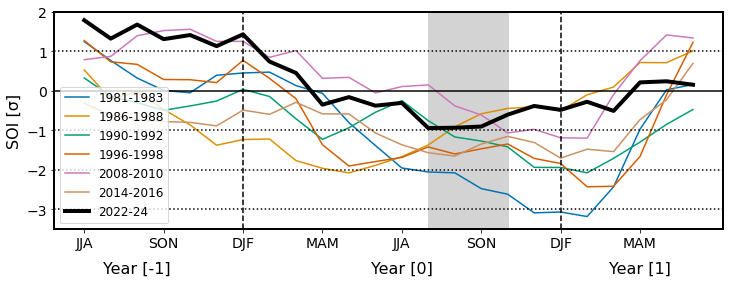

In [8]:

# Define event years
c_years = [1982, 1987, 1991, 1997, 2009,  2015]

# Get a nice color palette (e.g., Set2, colorblind, Paired)
colors = sns.color_palette("colorblind", len(c_years))  # Try "colorblind", "Set1", or "tab10"

fig, ax = plt.subplots(1, 1, figsize=(12, 4), sharey=True)

# Loop through historical years with better colors
for i, c in enumerate(c_years):
    ds_sel = soi.sel(time=slice(f"{c-1}-07", f"{c+1}-06"))
    ax.plot(np.arange(ds_sel.time.shape[0]), ds_sel.value, label=f"{c-1}-{c+1}", color=colors[i])

# Recent period in black, thicker line
ds_sel = soi.sel(time=slice("2022-07", "2024-06"))
ax.plot(np.arange(ds_sel.time.shape[0]), ds_sel.value, label="2022-24", color="k", linewidth=4)



#graphical stuff
# Set x-axis labels
xticks = [0,3,6,9, 12,15, 18, 21]  # Adjust ticks for clarity
xlabels = ['JJA', 'SON', 'DJF', 'MAM', 'JJA', 'SON', 'DJF', 'MAM']  # Representative months



ax.axhline(0, c = 'k')
ax.axhline(1, c = 'k', linestyle = ':')
ax.axhline(-1, c = 'k', linestyle = ':')
ax.axhline(2, c = 'k', linestyle = ':')
ax.axhline(-2, c = 'k', linestyle = ':')
ax.axhline(-3, c = 'k', linestyle = ':')


ax.fill_between(x = [13,16], y1 = 3, y2 = -4, color = 'lightgrey' )


ax.set_ylabel('SOI [σ]', fontsize = 16, fontweight = 'normal')
ax.set_xticks(xticks)
ax.set_xticklabels(xlabels, fontsize =16)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_ylim(-3.5, 2.)


ax.axvline(6, linestyle = '--', c = 'k')
ax.axvline(18, linestyle = '--', c = 'k')

    # Add a thick frame around the plot
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(2)

    # Second row: Manually add every 8th label slightly lower
for i in [2,12,21]:
    ax.text(i, -4.3, f"Year [{i//10 -1}]", ha="center", va="top", fontsize=16, color="black",
            fontweight ='normal')




ax.legend(fontsize= 12, loc = 'lower left')
#ax.set_title('ONI Evolution during El-Nino', fontweight = 'normal');

# Add title and format ticks

